# MA22018 Coursework 2

In [2]:
import numpy as np

def syntheticY(n):
    """
    Synthetic rank-2 n x n matrix
    """
    U = np.vstack((np.arange(n)/n, (1-np.arange(n)/n)**2)).T
    W = np.vstack((np.arange(n)/n, (1-np.arange(n)/n)**2)).T
    return U @ W.T

def bernoulli(mu,n,p,B):
    """
    Bernoulli sampling with the number of samples divisible by B.
    Produces a set of the first m index pairs I = {(i1,i2)} where
    i1 = 0,...,mu-1, i2 = 0,...,n-1, each pair 
    is sampled with probability p, and B divides m.
    """
    I = []
    for i1 in range(mu):
        for i2 in range(n):
            if np.random.rand()<p:
                I.append([i1,i2])
    return np.array(I[:B*(len(I)//B)])

def Loss(U,W,Y,I):
    """
    Loss function (2), where 
    U, W are n x r and mu x r factor matrices,
    Y is a mu x n data matrix, 
    and I is a m x 2 matrix of index pairs
    """
    L = 0
    for i1,i2 in I:
        L = L + (U[i1] @ W[i2] - Y[i1,i2])**2
    return L / I.shape[0]

def initial(mu,n,r):
    """
    Initial guess of the matrix factors
    """
    U0 = np.vstack((np.identity(r), np.zeros((mu-r,r))))
    W0 = np.vstack((np.identity(r), np.zeros((n-r,r))))
    return U0, W0


def test_pointwise_gradient_1():
    """
    Unit tests for the pointwise gradient
    """
    Y = syntheticY(4)
    U,W = initial(4,4,2)
    vu = np.array([0,-1.125])
    vw = np.array([-1.125,0])
    assert np.allclose(pointwise_gradient(U,W,Y,0,1)[0], vu), "wrong vu in test 1"
    assert np.allclose(pointwise_gradient(U,W,Y,0,1)[1], vw), "wrong vw in test 1"
    
def test_pointwise_gradient_2():
    Y = syntheticY(4)
    U,W = initial(4,4,2)
    vu = np.array([0,0])
    vw = np.array([-0.5,0])
    assert np.allclose(pointwise_gradient(U,W,Y,0,2)[0], vu), "wrong vu in test 2"
    assert np.allclose(pointwise_gradient(U,W,Y,0,2)[1], vw), "wrong vw in test 2"
    
def test_pointwise_gradient_3():
    Y = syntheticY(4)[:, 1:]
    U,W = initial(4,3,2)    
    vu = np.array([0,-0.625])
    vw = np.array([0,0])
    assert np.allclose(pointwise_gradient(U,W,Y,2,1)[0], vu), "wrong vu in test 3"
    assert np.allclose(pointwise_gradient(U,W,Y,2,1)[1], vw), "wrong vw in test 3"
    
    
def test_full_gradient_1():
    """
    Unit tests for the full gradient
    """
    Y = syntheticY(4)
    U,W = initial(4,4,2)
    Gu = np.array([[0,-1.125], [0,     0], [0,0], [0,0]])
    Gw = np.array([[0,     0], [-1.125,0], [0,0], [0,0]])
    assert np.allclose(full_gradient(U,W,Y, np.array([[0,1]]))[0], Gu), "wrong Gu in test 1"
    assert np.allclose(full_gradient(U,W,Y, np.array([[0,1]]))[1], Gw), "wrong Gw in test 1"
    
def test_full_gradient_2():
    Y = syntheticY(4)
    U,W = initial(4,4,2)
    Gu = np.array([[0,    0], [-9/16,0], [0,   0], [0,0]]) 
    Gw = np.array([[0,-9/16], [0,    0], [-1/4,0], [0,0]])
    assert np.allclose(full_gradient(U,W,Y, np.array([[1,0], [0,2]]))[0], Gu), "wrong Gu in test 2"
    assert np.allclose(full_gradient(U,W,Y, np.array([[1,0], [0,2]]))[1], Gw), "wrong Gw in test 2"
    
def test_full_gradient_3():
    Y = syntheticY(4)[:, 1:]
    U,W = initial(4,3,2)
    Gu = np.array([[0,-1/6], [-97/384,0], [0,-5/24], [0,0]]) 
    Gw = np.array([[0,-97/384], [-1/6,0], [0,   0]])
    assert np.allclose(full_gradient(U,W,Y, np.array([[1,0], [0,1], [2,1]]))[0], Gu), "wrong Gu in test 3"
    assert np.allclose(full_gradient(U,W,Y, np.array([[1,0], [0,1], [2,1]]))[1], Gw), "wrong Gw in test 3"

**Question 1**

In [3]:
import numpy as np

def pointwise_gradient(U,W,Y,i1,i2):
    ''' Calculate pointwise gradients for matrices U and W
    Input: Matrices U of shape (mu,r), W of shape (n,r) and Y of shape (mu,n). Two indexes, i1 integer from 0 to mu-1 inc.,
    i2 integer from 0 to n-1 inc.
    Output: Two np arrays of shape (r,), one is vu and one vw.
    '''
    u_row_i1 = U[i1]
    w_row_i2 = W[i2]
    wt_i2 = w_row_i2.reshape(-1,1) # Tranposes row into correct shape for multiplication
    y_i1_i2 = Y[i1][i2]
    vu = 2 * (((u_row_i1 @ wt_i2) - y_i1_i2) * w_row_i2)
    vw = 2 * (((u_row_i1 @ wt_i2) - y_i1_i2) * u_row_i1)
    return vu, vw

**Question 2**

In [4]:
import numpy as np

def full_gradient(U,W,Y,I):
    '''
    Implementing Algorithm 2 of the coursework.
    Input: Matrices U of shape (mu,r), W of shape (n,r) and Y of shape (mu,n). I as a numpy array of shape(m,2)
    Output: Two np arrays, Gu of shape (mu,r) and Gw of shape(n,r)
    '''
    # Set up parameters
    mu,r = U.shape
    n = W.shape[0]
    m = I.shape[0]
    # Initalise Gu and Gw
    Gu = np.zeros((mu,r))
    Gw = np.zeros((n,r))
    # Create loop to iterate over every element in I
    for i1,i2 in I: 
        vu, vw = pointwise_gradient(U,W,Y,i1,i2)
        Gu[i1] = Gu[i1] + vu # Can just add the rows without using additional for loops
        Gw[i2] = Gw[i2] + vw
    Gu = Gu / m
    Gw = Gw / m
    return Gu, Gw

In [5]:
# Testing, should print None each time
print(test_pointwise_gradient_1())
print(test_pointwise_gradient_2())
print(test_pointwise_gradient_3())
print(test_full_gradient_1())  
print(test_full_gradient_2())  
print(test_full_gradient_3())  

None
None
None
None
None
None


**Question 3**

In [6]:
import numpy as np
from copy import deepcopy
from matplotlib import pyplot as plt

def sgd(U0,W0,Y,I,B=2,t=1,dk=100,q=0.99,K=1000):
    '''
    Implementing Algorithm 3 of the coursework (Stochastic Gradient Descent)
    Inputs: U0 numpy array of shape (mu,r), W0 numpy array of shape (n,r), Y numpy array of shape (mu,n), I numpy array of shape(m,2)
    B,dk,K natural numbers, t,q > 0
    Outputs: Uk* numpy array of shape (mu,r), Wk* numpy array of shape (n,r)
    '''
    # Shuffle the rows of I randomly
    np.random.shuffle(I) # In np docs specifies that multi dimensional arrays only shuffled over first axis (the rows)
    mini_batches = np.array_split(I,B) # In np docs it says that array_splits can also deal with the case when the number of batches doesn't perfectly
    # divide the number of rows as opposed to np.split which returns an error for that case
    # Initialise variables for loops
    u_current = deepcopy(U0) # Using deepcopy whenever we are reassigning matrices to avoid any errors from overwriting
    w_current = deepcopy(W0)
    u_candidate = deepcopy(U0)
    w_candidate = deepcopy(W0)
    b = 1
    test_loss_values = []
    current_best_loss = Loss(u_current,w_current,Y,mini_batches[0])
    for k in range(K):
        current_loss = Loss(u_current,w_current,Y,mini_batches[0])
        test_loss_values.append(current_loss)
        if current_loss < current_best_loss:
            # Update ustar and wstar and keep track of the iteration number at which this occurred
            current_best_loss = current_loss
            u_candidate = deepcopy(u_current)
            w_candidate = deepcopy(w_current)
            kstar = k
        if k >= dk and test_loss_values[k] > (q * test_loss_values[k - dk]):
            break
        Gu, Gw = full_gradient(u_current,w_current,Y,mini_batches[b])
        # Update iterates
        u_current = u_current - (t * Gu)
        w_current = w_current - (t * Gw)
        if b < B - 1:
            b += 1
        else:
            b = 1
    plt.semilogy(range(len(test_loss_values)), test_loss_values) # Creates a plot with a logarithmic y-axis
    plt.xlabel('Iteration number K')
    plt.ylabel('Log of the Test loss value')
    plt.title('Loss values in logarithmic scale as a function of the iteration number K')
    plt.show()
    return u_candidate, w_candidate, kstar, current_best_loss, len(test_loss_values) - 1 # Also return the time to converge and the loss at that occurrence

**Question 4**

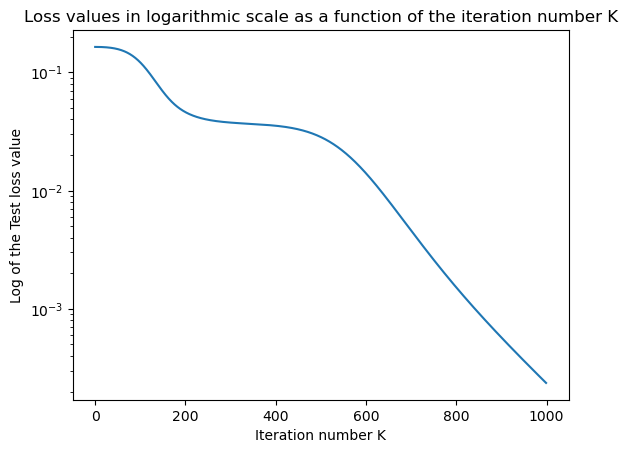

For t = 1 the algorithm converges in 999 iterations, kstar = 999
CPU times: user 7.87 s, sys: 41.2 ms, total: 7.91 s
Wall time: 8.2 s


In [7]:
%%time
# Test that sgd function works
n = 30
Y = syntheticY(n)
I = bernoulli(n,n,1,10) # Set undersampling factor p = 1.
U0, W0 = initial(n,n,2)
result = sgd(U0,W0,Y,I)
print(f"For t = 1 the algorithm converges in {result[4]} iterations, kstar = {result[2]}")

In [10]:
%%time 
# Now we are going to find an optimal t
import numpy as np
from copy import deepcopy
from matplotlib import pyplot as plt
n = 30
Y = syntheticY(n)
I = bernoulli(n,n,1,10)
U0, W0 = initial(n,n,2)

# Define a function but without the plotting so we don't end up with many graphs
def sgd_plotless(U0,W0,Y,I,B=2,t=1,dk=100,q=0.99,K=1000):
    '''
    sgd but without the plotting part.
    Inputs: U0 numpy array of shape (mu,r), W0 numpy array of shape (n,r), Y numpy array of shape (mu,n), I numpy array of shape(m,2)
    B,dk,K natural numbers, t,q > 0
    Outputs: Uk* numpy array of shape (mu,r), Wk* numpy array of shape (n,r)
    '''
    # Shuffle the rows of I randomly
    np.random.shuffle(I) # In np docs specifies that multi dimensional arrays only shuffled over first axis (the rows)
    mini_batches = np.array_split(I,B) # In np docs it says that array_splits can also deal with the case when the number of batches doesn't perfectly
    # divide the number of rows as opposed to np.split which returns an error for that case
    # Initialise variables for loops
    u_current = deepcopy(U0) # Using deepcopy whenever we are reassigning matrices to avoid any errors from overwriting
    w_current = deepcopy(W0)
    u_candidate = deepcopy(U0)
    w_candidate = deepcopy(W0)
    b = 1
    test_loss_values = []
    current_best_loss = Loss(u_current,w_current,Y,mini_batches[0])
    for k in range(K):
        current_loss = Loss(u_current,w_current,Y,mini_batches[0])
        test_loss_values.append(current_loss)
        if current_loss < current_best_loss:
            # Update ustar and wstar and keep track of the iteration number at which this occurred
            current_best_loss = current_loss
            u_candidate = deepcopy(u_current)
            w_candidate = deepcopy(w_current)
            kstar = k
        if k >= dk and test_loss_values[k] > (q * test_loss_values[k - dk]):
            break
        Gu, Gw = full_gradient(u_current,w_current,Y,mini_batches[b])
        # Update iterates
        u_current = u_current - (t * Gu)
        w_current = w_current - (t * Gw)
        if b < B - 1:
            b += 1
        else:
            b = 1
    return u_candidate, w_candidate, kstar, current_best_loss, len(test_loss_values) - 1 # Also return the time to converge and the loss at that occurrence

n_runs = 5
potential_t = [1,2,4,8,16,32] # Note that 64 is not included as due to the learning rate being too large it overshoots
# and diverges causing RuntimeWarnings due to overflow errors.
average_losses = []
average_runs_for_convergence = []
average_kstar = []
for pot_t in potential_t:
    loss_total = 0
    convergence_total = 0
    kstar_total = 0
    for i in range(n_runs):
        run = sgd_plotless(U0,W0,Y,I,B=10,dk=100,q=0.99,K=1000,t=pot_t) # Overriding the parameters as required
        print(f"For run {i+1} of t = {pot_t}, kstar = {run[2]}, algorithm stops at k = {run[4]} and lowest loss = {run[3]}") # Helps to keep track
        loss_total += run[3]
        convergence_total += run[4]
        kstar_total += run[2]
    average_losses.append(loss_total / n_runs)
    average_runs_for_convergence.append(convergence_total / n_runs)
    average_kstar.append(kstar_total / n_runs)

for i in range(len(potential_t)):
    print(f"For t = {potential_t[i]} the average lowest loss was {average_losses[i]}, average k algorithm stopped at was {average_runs_for_convergence[i]} and average kstar was {average_kstar[i]}.")

For run 1 of t = 1, kstar = 999, algorithm stops at k = 999 and lowest loss = 1.0012155757253832e-07
For run 2 of t = 1, kstar = 999, algorithm stops at k = 999 and lowest loss = 3.04703581596927e-07
For run 3 of t = 1, kstar = 999, algorithm stops at k = 999 and lowest loss = 2.277238389578259e-06
For run 4 of t = 1, kstar = 999, algorithm stops at k = 999 and lowest loss = 8.577379644628279e-08
For run 5 of t = 1, kstar = 207, algorithm stops at k = 275 and lowest loss = 0.04319144433062529
For run 1 of t = 2, kstar = 101, algorithm stops at k = 179 and lowest loss = 0.04834473354781654
For run 2 of t = 2, kstar = 999, algorithm stops at k = 999 and lowest loss = 1.437334261617092e-14
For run 3 of t = 2, kstar = 999, algorithm stops at k = 999 and lowest loss = 2.482853653273791e-10
For run 4 of t = 2, kstar = 999, algorithm stops at k = 999 and lowest loss = 1.7571542987892484e-12
For run 5 of t = 2, kstar = 999, algorithm stops at k = 999 and lowest loss = 6.176988043475601e-16
For

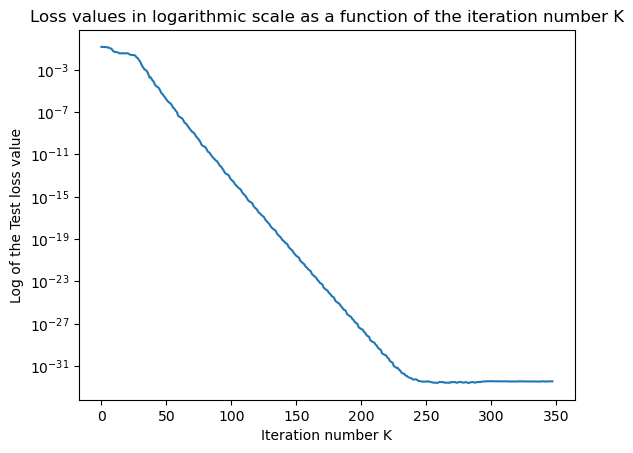

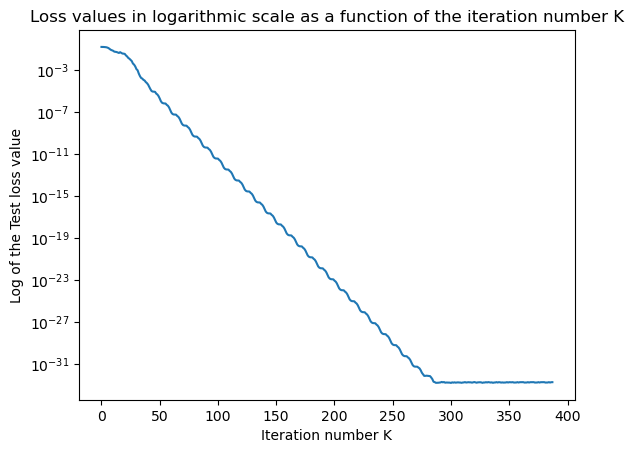

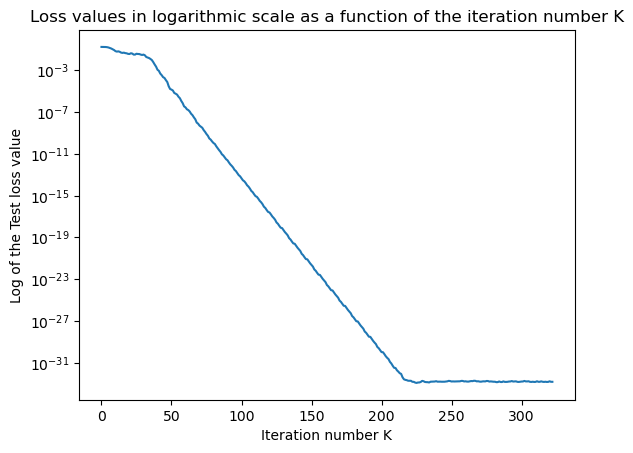

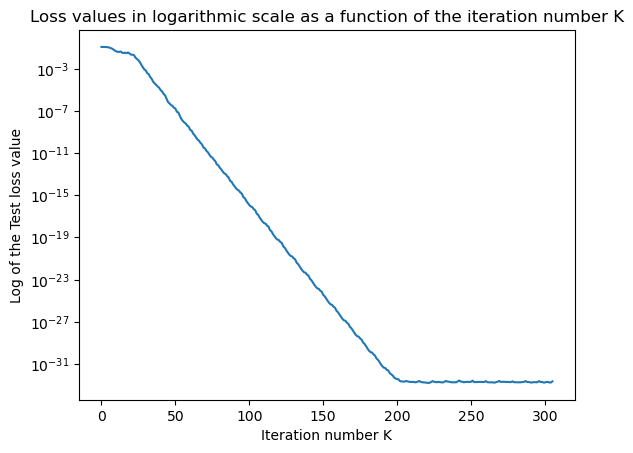

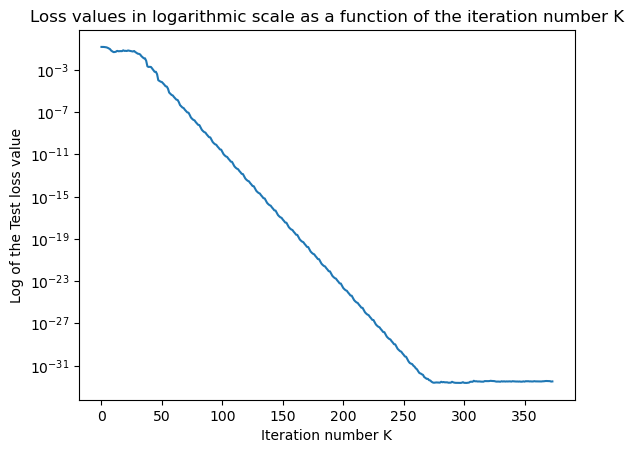

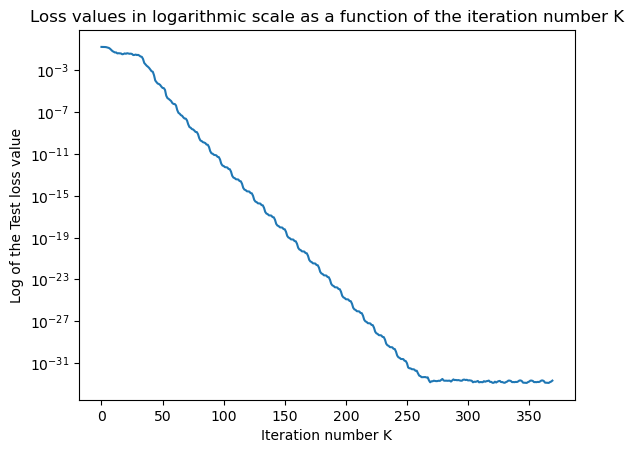

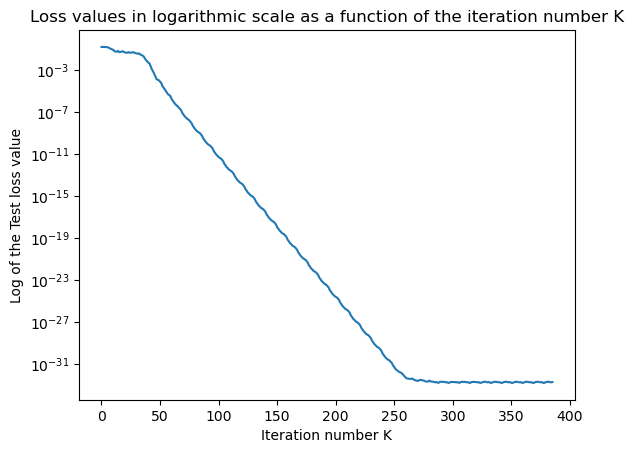

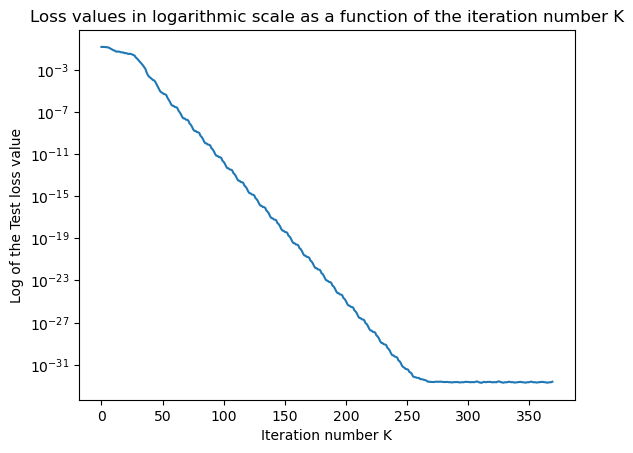

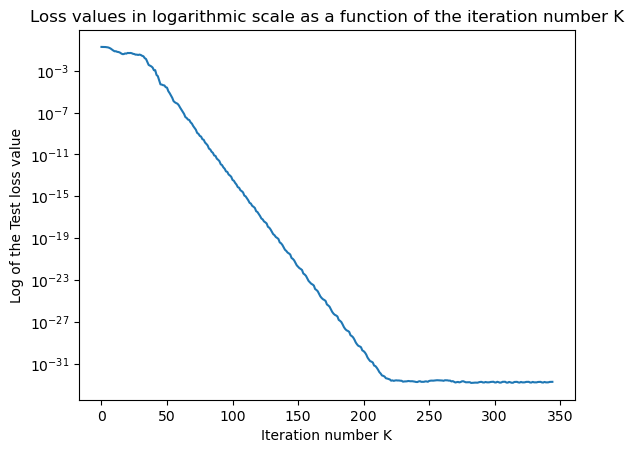

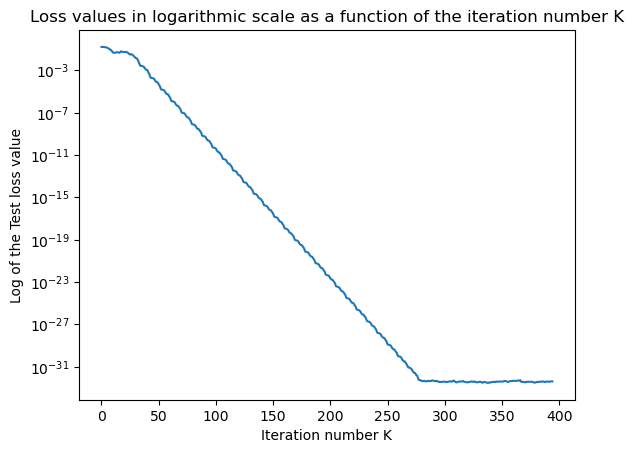

Average total relative error was 1.0562642019920426e-16
Average kstar was 293.7
Average lowest loss was 1.845542169758356e-33
Average iterations per algorithm was 360.5


In [11]:
import numpy as np
from numpy.linalg import norm

# Now lets study t = 16 closer as it is giving the best results
n = 30
Y = syntheticY(n)
I = bernoulli(n,n,1,10)
U0, W0 = initial(n,n,2)

n_runs = 10
average_error = 0
average_loss = 0
average_kstar = 0
average_runs = 0
for i in range(n_runs):
    run = sgd(U0,W0,Y,I,B=10,dk=100,q=0.99,K=1000,t=16) # Can use original sgd now as we want to plot it
    U = run[0]
    WT = run[1].transpose()
    total_relative_error = norm(((U @ WT) - Y),'fro') / norm(Y,'fro') # Fro signifies the use of the Frobenius norm
    average_error += total_relative_error
    average_loss += run[3]
    average_kstar += run[2]
    average_runs += (run[4] + 1)

print(f"Average total relative error was {average_error / n_runs}")
print(f"Average kstar was {average_kstar / n_runs}")
print(f"Average lowest loss was {average_loss / n_runs}")
print(f"Average iterations per algorithm was {average_runs / n_runs}")

**Question 5**

In [12]:
# Load the data from the file
import numpy as np
data = np.load('CW2.npz')
matrix = data['Y']
print(matrix.shape)
mu = 25 ** 2
n = 49
r = 4
Y = matrix.reshape(mu, n)
print(Y.shape) # Check the shape of the matrices to make sure that the data is extracted correctly

(25, 25, 49)
(625, 49)


In [16]:
%%time
I = bernoulli(mu,n,1/3,10)
U0, W0 = initial(mu,n,r)

# Need to vary t and B within the ranges set
n_runs = 1 # Anything more than this causes an incredibly long run time. This block takes about 6 and a half minutes to run
t_tries = [1,2,4,8,16,32] # Using the same range given in Q4 with 64 excluded again as it creates the same errors for the real data as it did the synthetic data.
b_options = [2,5,10,20]
t_and_b = []
for t_try in t_tries:
    for b_try in b_options:
        print('Iteration completed') # Helps reader to keep track of iterations
        loss_total = 0
        iterations_total = 0
        for i in range(n_runs):
            run = sgd_plotless(U0,W0,Y,I,B=b_try,dk=100,q=0.99,K=1000,t=t_try)
            loss_total += run[3]
            iterations_total += run[2]
        summary_obj = [[t_try,b_try],[loss_total / n_runs,iterations_total / n_runs]]
        t_and_b.append(summary_obj)
print(t_and_b)

Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
Iteration completed
[[[1, 2], [2.378539150817966, 100.0]], [[1, 5], [2.403168483881045, 100.0]], [[1, 10], [2.2199890006881, 100.0]], [[1, 20], [2.2769024705106986, 100.0]], [[2, 2], [0.058369885624098436, 562.0]], [[2, 5], [0.044689868974261034, 398.0]], [[2, 10], [0.04949640986663533, 420.0]], [[2, 20], [0.047902448932566226, 359.0]], [[4, 2], [0.044874110649707394, 999.0]], [[4, 5], [0.04363107942998958, 333.0]], [[4, 10], [0.045631097185784536, 200.0]], [[4, 20], [0.04435866681912991, 157.0]], [[8, 2], [0.06731991507405519, 137.0]

[[[1, 2], [2.378539150817966, 100.0]], [[1, 5], [2.403168483881045, 100.0]], [[1, 10], [2.2199890006881, 100.0]], [[1, 20], [2.2769024705106986, 100.0]], [[2, 2], [0.058369885624098436, 562.0]], [[2, 5], [0.044689868974261034, 398.0]], [[2, 10], [0.04949640986663533, 420.0]], [[2, 20], [0.047902448932566226, 359.0]], [[4, 2], [0.044874110649707394, 999.0]], [[4, 5], [0.04363107942998958, 333.0]], [[4, 10], [0.045631097185784536, 200.0]], [[4, 20], [0.04435866681912991, 157.0]], [[8, 2], [0.06731991507405519, 137.0]], [[8, 5], [0.04773714248848888, 93.0]], [[8, 10], [0.04441228566605276, 168.0]], [[8, 20], [0.0406965181573982, 69.0]], [[16, 2], [0.06311584497776879, 100.0]], [[16, 5], [0.013680100557702557, 996.0]], [[16, 10], [0.008669262792180037, 913.0]], [[16, 20], [0.011972004847155568, 665.0]], [[32, 2], [0.05590208133688918, 245.0]], [[32, 5], [0.013192370111505581, 507.0]], [[32, 10], [0.009317177347008916, 538.0]], [[32, 20], [0.014606410153757373, 371.0]]]


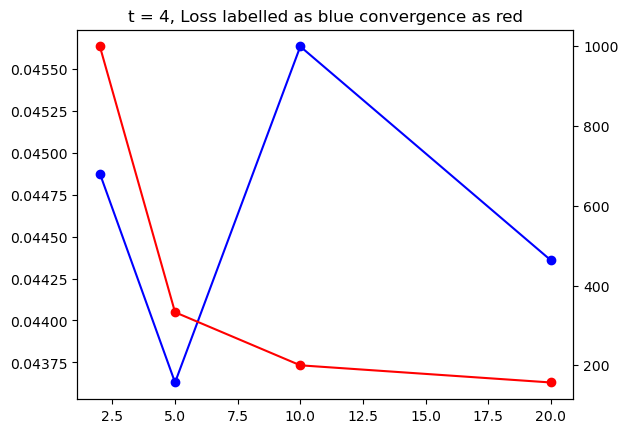

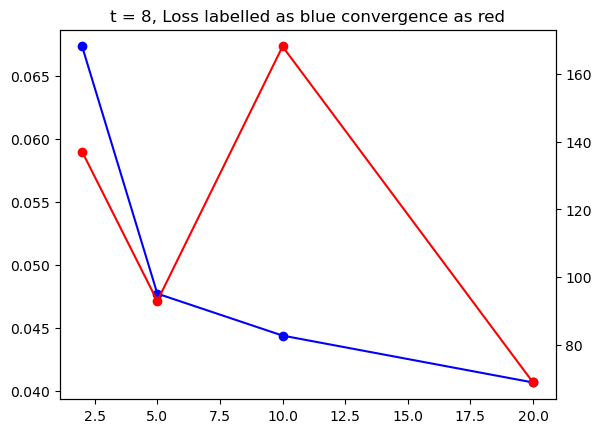

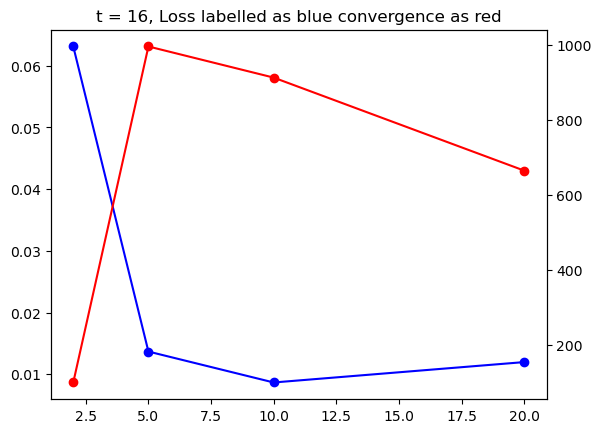

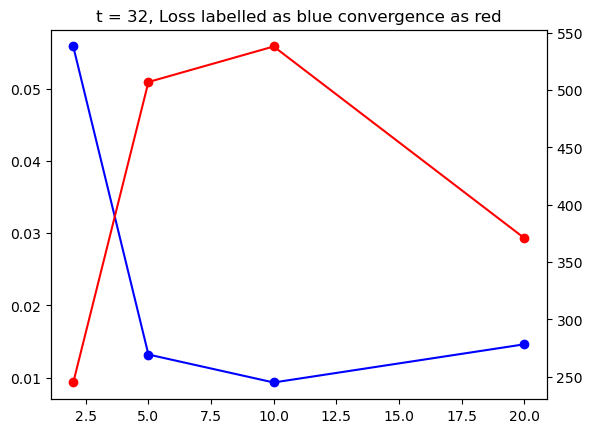

CPU times: user 555 ms, sys: 48 ms, total: 603 ms
Wall time: 640 ms


In [17]:
%%time
from matplotlib import pyplot as plt

print(t_and_b)

for i in [4,8,16,32]:
    t_loss = [element[1][0] for element in t_and_b if element[0][0] == i]
    t_convergence = [element[1][1] for element in t_and_b if element[0][0] == i]
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot([2,5,10,20],t_loss,marker='o',color='b')
    ax2.plot([2,5,10,20],t_convergence,marker='o',color='r')
    plt.title(f"t = {i}, Loss labelled as blue convergence as red")
    plt.show()

Plot of run 1 for t=4, b=10


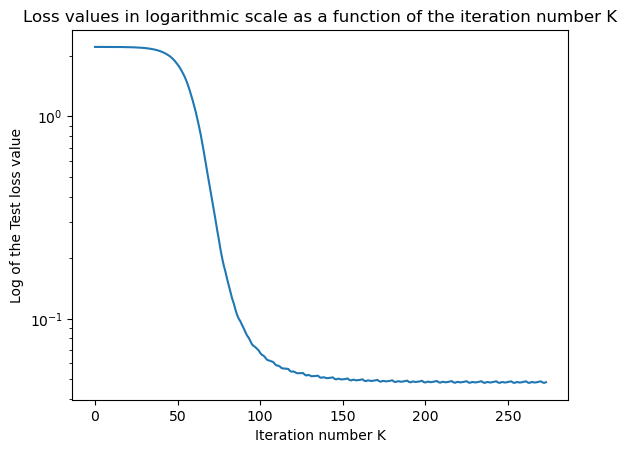

Plot of run 2 for t=4, b=10


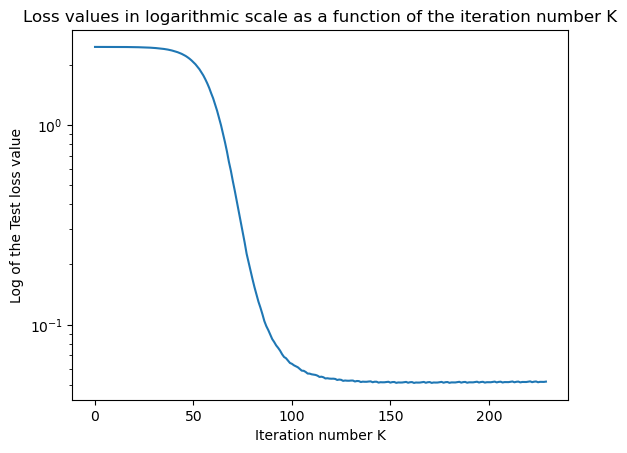

Plot of run 3 for t=4, b=10


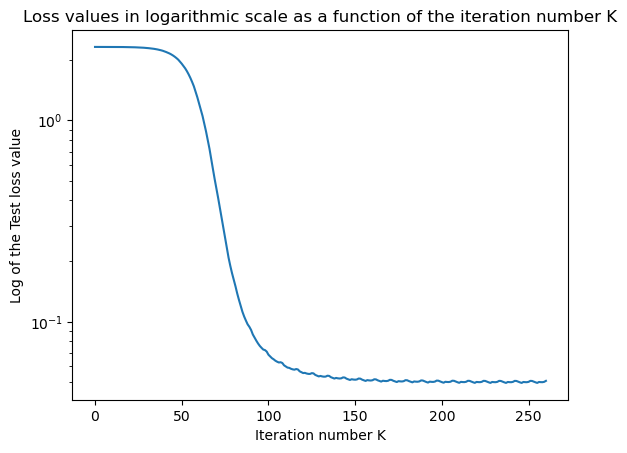

Plot of run 4 for t=4, b=10


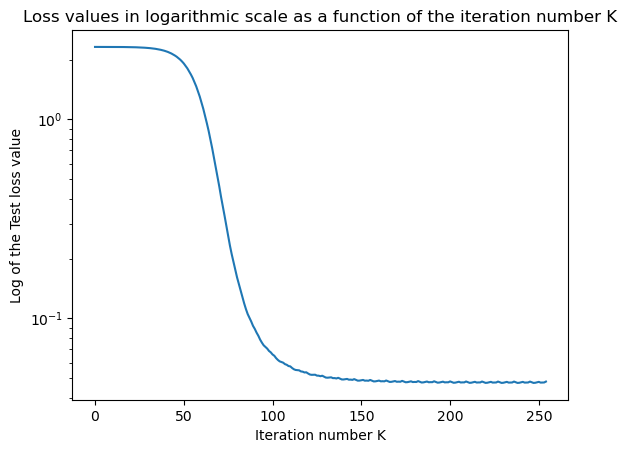

Plot of run 5 for t=4, b=10


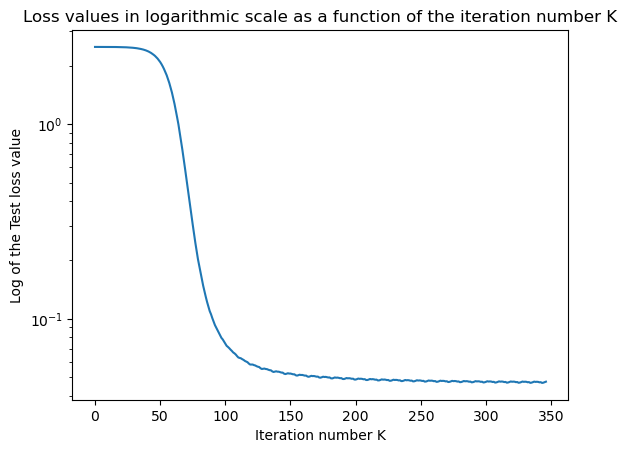

Plot of run 1 for t=8, b=20


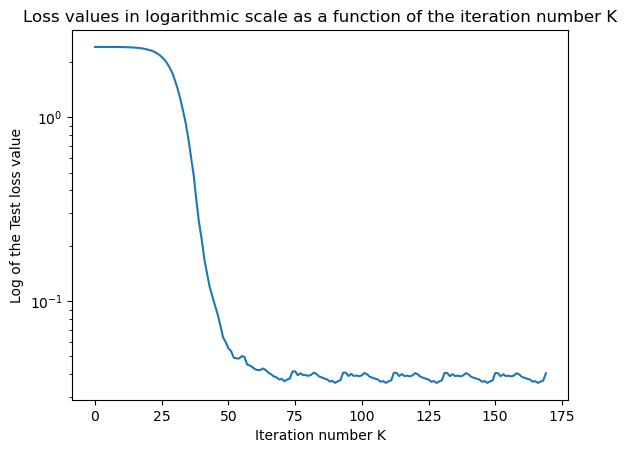

Plot of run 2 for t=8, b=20


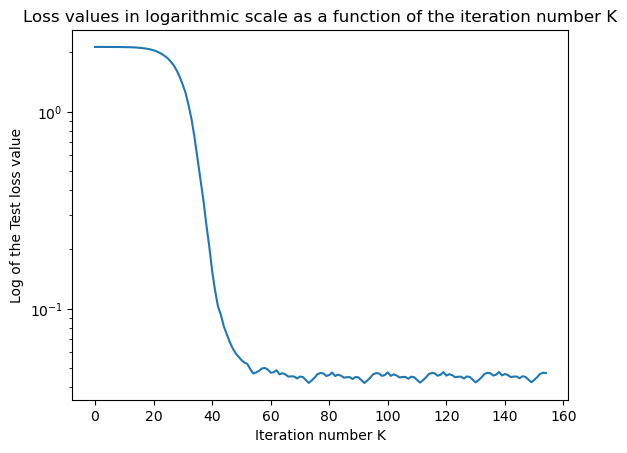

Plot of run 3 for t=8, b=20


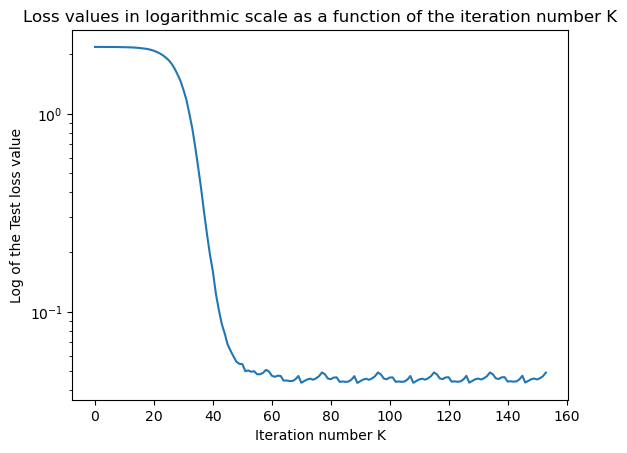

Plot of run 4 for t=8, b=20


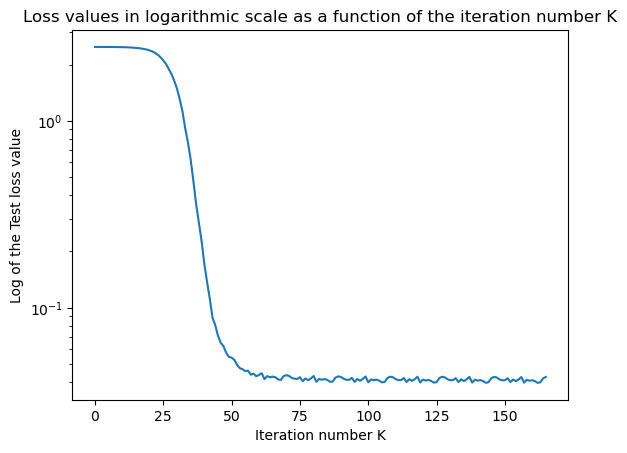

Plot of run 5 for t=8, b=20


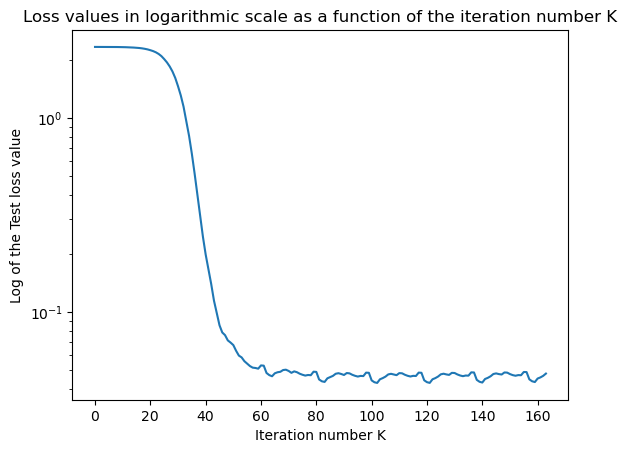

Plot of run 1 for t=16, b=20


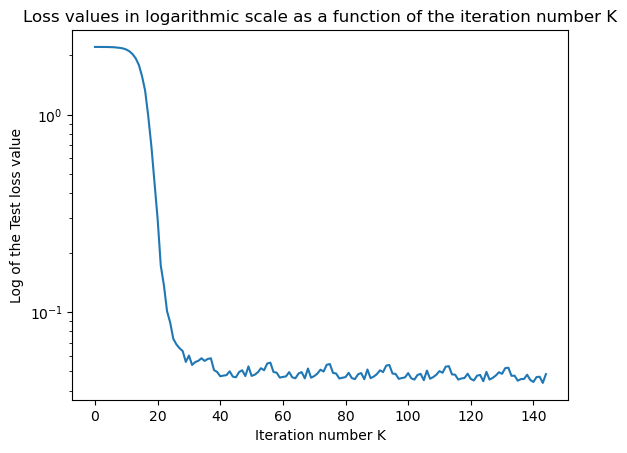

Plot of run 2 for t=16, b=20


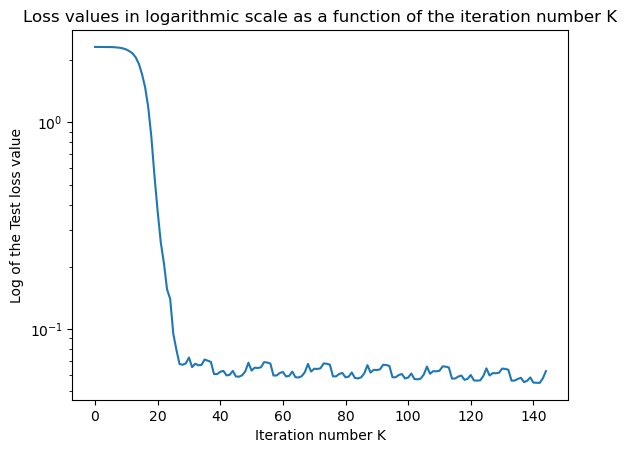

Plot of run 3 for t=16, b=20


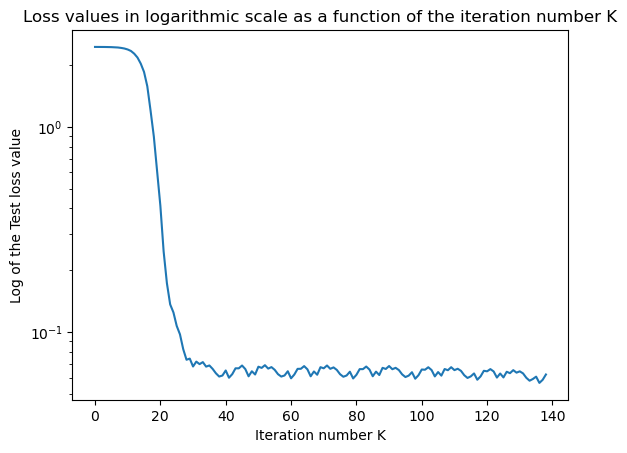

Plot of run 4 for t=16, b=20


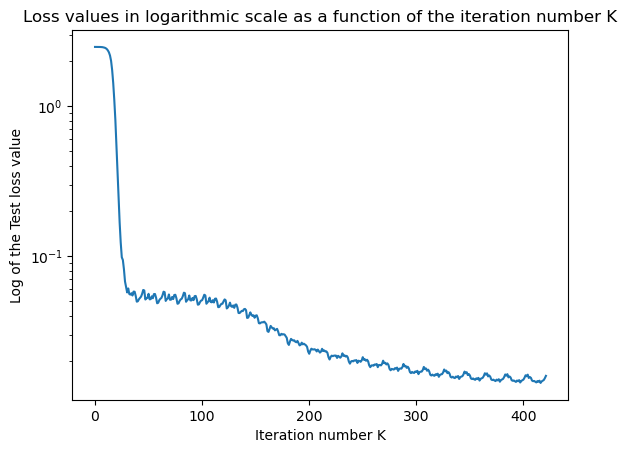

Plot of run 5 for t=16, b=20


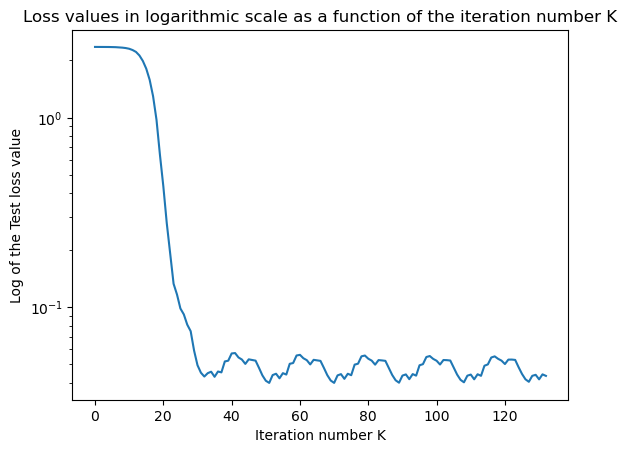

Plot of run 1 for t=32, b=20


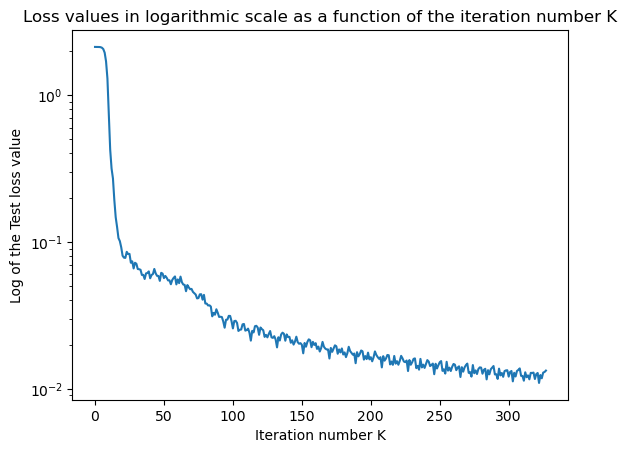

Plot of run 2 for t=32, b=20


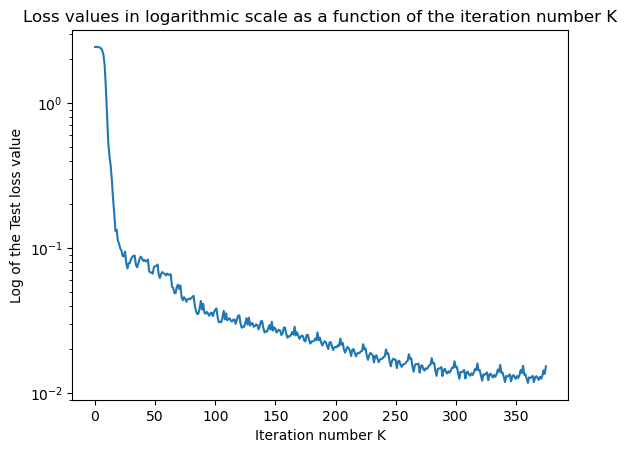

Plot of run 3 for t=32, b=20


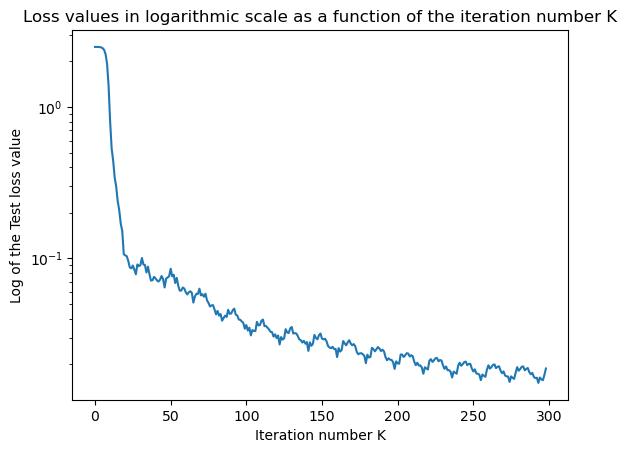

Plot of run 4 for t=32, b=20


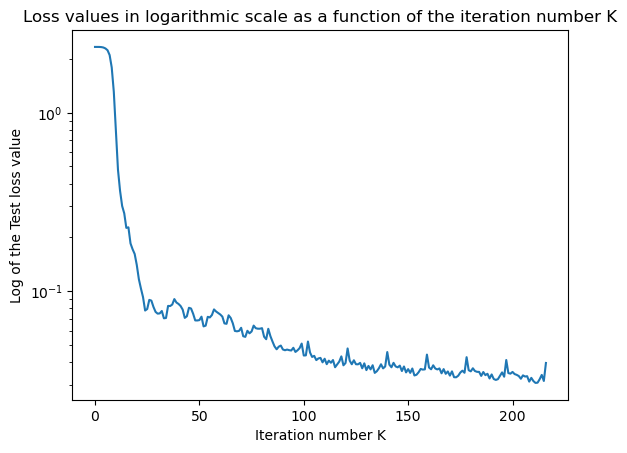

Plot of run 5 for t=32, b=20


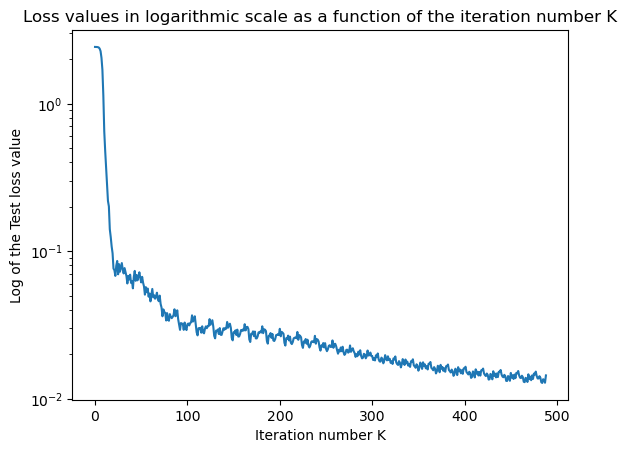

For t = 4, b= 10, average loss = 0.048543213089860794, average error = 0.13453497125605418, average kstar = 248.6, average k at convergence = 272.4
For t = 8, b= 20, average loss = 0.04083491028786567, average error = 0.13736037038759888, average kstar = 122.2, average k at convergence = 160.8
For t = 16, b= 20, average loss = 0.041854169359705914, average error = 0.12931681285451935, average kstar = 177.6, average k at convergence = 195.8
For t = 32, b= 20, average loss = 0.016230311265713407, average error = 0.07790832385068029, average kstar = 334.0, average k at convergence = 340.8
CPU times: user 1min, sys: 728 ms, total: 1min 1s
Wall time: 1min 4s


In [18]:
%%time
import numpy as np
from numpy.linalg import norm
# Lets try the best t for each b and compare

I = bernoulli(mu,n,1/3,10)
U0, W0 = initial(mu,n,r)

combos = [[4,10],[8,20],[16,20],[32,20]]

n_runs = 5

average_losses = []
average_errors = []
average_kstar = []
average_k_convergence = []

for combo in combos:
    loss = 0
    error = 0
    kstar = 0
    k_conv = 0
    t_try = combo[0]
    b_try = combo[1]
    for i in range(n_runs):
        print(f"Plot of run {i + 1} for t={combo[0]}, b={combo[1]}")
        run = sgd(U0,W0,Y,I,B=b_try,dk=100,q=0.99,K=1000,t=t_try)
        loss += run[3]
        k_conv += run[4]
        kstar += run[2]
        U = run[0]
        WT = run[1].transpose()
        error += norm((U @ WT) - Y, 'fro') / norm(Y,'fro')
    average_losses.append(loss / n_runs)
    average_errors.append(error / n_runs)
    average_kstar.append(kstar / n_runs)
    average_k_convergence.append(k_conv / n_runs)

for i in range(4):
    print(f"For t = {combos[i][0]}, b= {combos[i][1]}, average loss = {average_losses[i]}, average error = {average_errors[i]}, average kstar = {average_kstar[i]}, average k at convergence = {average_k_convergence[i]}")


**Question 6**

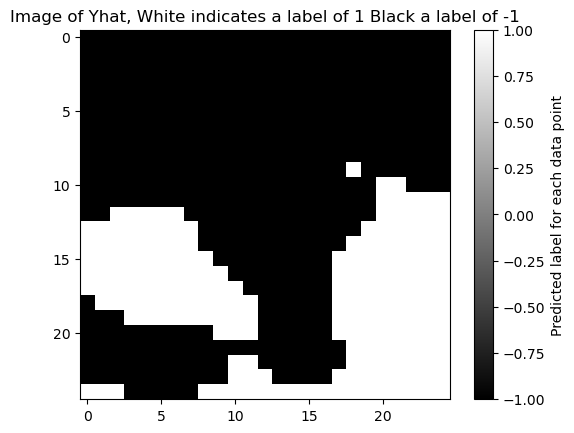

In [21]:
import numpy as np
from sklearn.svm import SVC
from matplotlib import pyplot as plt

data = np.load('CW2.npz')
matrix = data['Y']
Y = matrix.reshape(25**2,49)
Y_minus_data = matrix[:5, :5, :49]
Y_plus_data = matrix[20:25,20:25, :49]
Y_minus = Y_minus_data.reshape(25,49)
Y_plus = Y_plus_data.reshape(25,49)

# Now we label them
minus_labels = np.full(Y_minus.shape[0],-1)
plus_labels = np.full(Y_plus.shape[0],1)

X = np.vstack([Y_minus, Y_plus]) # This is our observed data for training
y = np.hstack([minus_labels,plus_labels])  # Labels for training (-1 for Y_minus, 1 for Y_plus)

svm = SVC(kernel='linear',C=0.01) # Using implementation in week 6, kernel='linear' ensures the hyperplane is a straight line
svm.fit(X, y) # Trains the model based on the rows and data we already have

yhat = svm.predict(Y) # Predicts the labels for the whole matrix
yhat_matrix = yhat.reshape(25, 25) # Creates a matrix out of the labels

plt.imshow(yhat_matrix,cmap='grey') # Changing the cmap makes the image easier to interpret
plt.colorbar(label='Predicted label for each data point')
plt.title('Image of Yhat, White indicates a label of 1 Black a label of -1')
plt.show()